## Data Preprocess

In [36]:
from pandas import read_csv

dataframe = read_csv('../3D-MLGM_dataset.csv', usecols=[0])  # get X data
dataset = dataframe.values
dataset = dataset.astype('float32')
X = dataset[:5000]
# print(X.shape)
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1


## Visualize train test dataset

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def plot_train_test(X_train, y_train, X_test, y_test):
    sample = 1000
    test_len = X_test.shape[0]
    fig = plt.figure(figsize=(15, 5))
    # plt.scatter(np.arange(0, sample), X_train[-sample:], label="Training data")
    # plt.scatter(np.arange(0, sample), y_train[-sample:], label="Training ground truth")
    # plt.scatter(np.arange(sample, sample+test_len), X_test, label="Testing data")
    # plt.scatter(np.arange(sample, sample+test_len), y_test, label="Testing ground truth")
    plt.plot(np.arange(0, sample), X_train[-sample:], label="Training data")
    plt.plot(np.arange(0, sample), y_train[-sample:], label="Training ground truth")
    plt.plot(np.arange(sample, sample+test_len), X_test, label="Testing data")
    plt.plot(np.arange(sample, sample+test_len), y_test, label="Testing ground truth")
    plt.legend()
    plt.show()

(4000, 1) (4000, 1)
(999, 1) (999, 1)


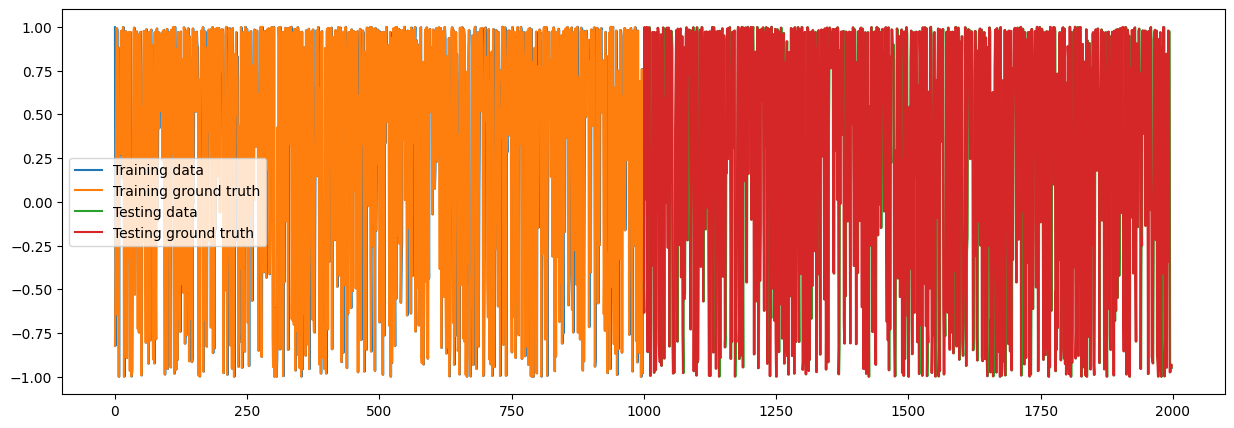

In [113]:
from reservoirpy.datasets import to_forecasting

x, y = to_forecasting(X, forecast=1)
X_train1, y_train1 = x[:4000], y[:4000]
X_test1, y_test1 = x[4000:], y[4000:]
print(X_train1.shape, y_train1.shape)
print(X_test1.shape, y_test1.shape)

plot_train_test(X_train1, y_train1, X_test1, y_test1)

## Experiment 1: Long-term prediction

Predict $P(t+10)$ given $P(t)$ 

### Build ESN

Running Model-34: 4000it [00:00, 9351.40it/s]<?, ?it/s]
Running Model-34: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]


Fitting node Ridge-34...


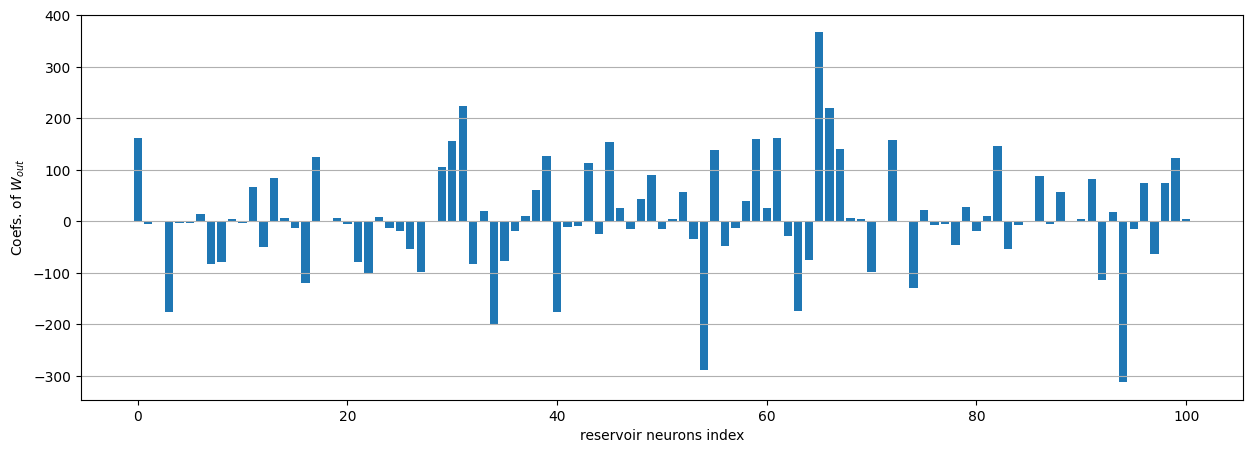

Running Model-34: 999it [00:00, 9495.91it/s]           


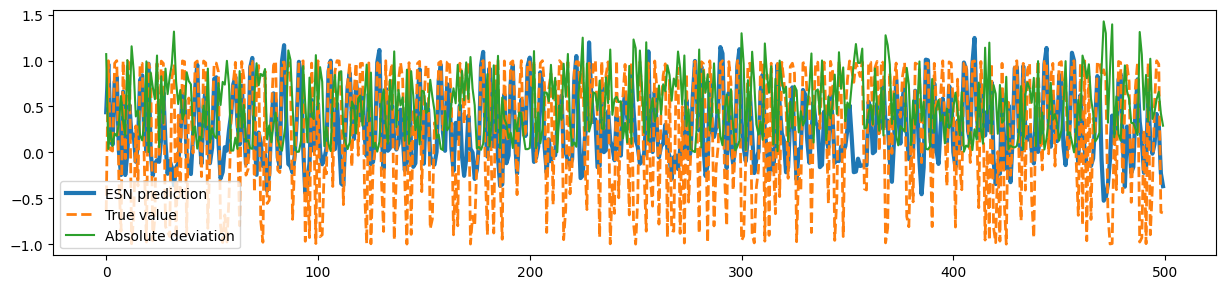

R2 = 0.31230006953399914, RMSE = 0.3125110182088758


In [126]:
units = 100
leak_rate = 0.3
spectral_radius = 1.25
input_scaling = 1.0
connectivity = 0.1
input_connectivity = 0.2
regularization = 1e-8
seed = 1234

def reset_esn():
    from reservoirpy.nodes import Reservoir, Ridge

    reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                          lr=leak_rate, rc_connectivity=connectivity,
                          input_connectivity=input_connectivity, seed=seed)
    readout   = Ridge(1, ridge=regularization)

    return reservoir >> readout

from reservoirpy.nodes import Reservoir, Ridge

reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                      lr=leak_rate, rc_connectivity=connectivity,
                      input_connectivity=input_connectivity, seed=seed)

readout   = Ridge(1, ridge=regularization)

esn = reservoir >> readout

y = esn(X[0])  # initialisation

# reservoir.Win is not None, reservoir.W is not None, readout.Wout is not None
# np.all(readout.Wout == 0.0)
esn = esn.fit(X_train1, y_train1)

def plot_readout(readout):
    Wout = readout.Wout
    bias = readout.bias
    Wout = np.r_[bias, Wout]

    fig = plt.figure(figsize=(15, 5))

    ax = fig.add_subplot(111)
    ax.grid(axis="y")
    ax.set_ylabel("Coefs. of $W_{out}$")
    ax.set_xlabel("reservoir neurons index")
    ax.bar(np.arange(Wout.size), Wout.ravel()[::-1])

    plt.show()

plot_readout(readout)

def plot_results(y_pred, y_test, sample=500):

    fig = plt.figure(figsize=(15, 7))
    plt.subplot(211)
    plt.plot(np.arange(sample), y_pred[:sample], lw=3, label="ESN prediction")
    plt.plot(np.arange(sample), y_test[:sample], linestyle="--", lw=2, label="True value")
    plt.plot(np.abs(y_test[:sample] - y_pred[:sample]), label="Absolute deviation")

    plt.legend()
    plt.show()

y_pred1 = esn.run(X_test1)
plot_results(y_pred1, y_test1)

from reservoirpy.observables import nrmse, rsquare
print(f'R2 = {rsquare(y_test1, y_pred1)}, RMSE = {nrmse(y_test1, y_pred1)}')

Running Model-41:   0%|          | 0/1 [00:00<?, ?it/s]

Running Model-41: 4000it [00:00, 10131.73it/s]
Running Model-41: 100%|██████████| 1/1 [00:00<00:00,  2.49it/s]


Fitting node Ridge-41...


Running Model-41: 100it [00:00, 5726.48it/s]           


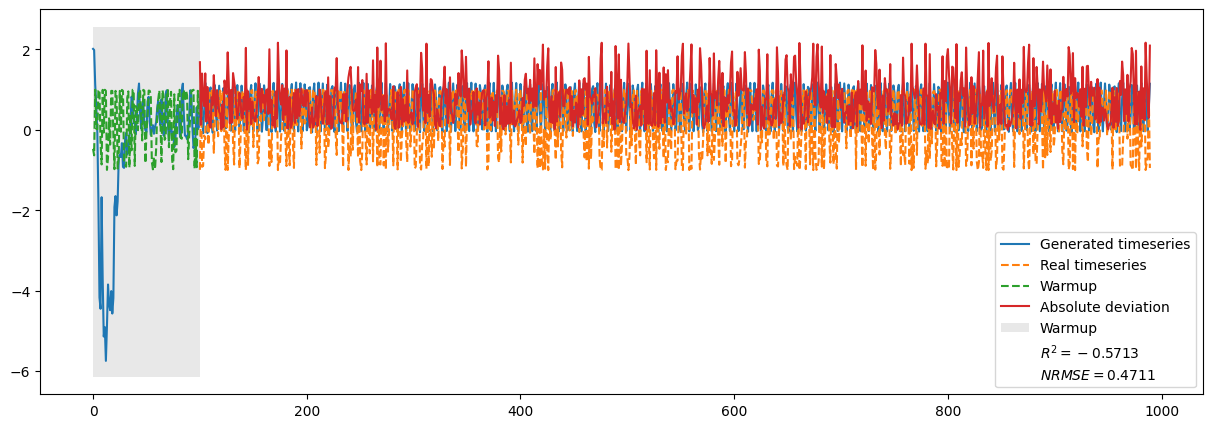

In [133]:
esn = reset_esn()

x, y = to_forecasting(X, forecast=1)
X_train2, y_train2 = x[:4000], y[:4000]
X_test2, y_test2 = x[4000:], y[4000:]

esn = esn.fit(X_train2, y_train2)

seed_timesteps = 100
warming_inputs = X_test2[:seed_timesteps]
warming_out = esn.run(warming_inputs, reset=True)  # warmup

def plot_generation(X_gen, X_t, nb_generations, warming_out=None, warming_inputs=None, seed_timesteps=0):

    plt.figure(figsize=(15, 5))
    if warming_out is not None:
        plt.plot(np.vstack([warming_out, X_gen]), label="Generated timeseries")
    else:
        plt.plot(X_gen, label="Generated timeseries")

    plt.plot(np.arange(nb_generations)+seed_timesteps, X_t, linestyle="--", label="Real timeseries")

    if warming_inputs is not None:
        plt.plot(np.arange(seed_timesteps), warming_inputs, linestyle="--", label="Warmup")

    plt.plot(np.arange(nb_generations)+seed_timesteps, np.abs(X_t - X_gen),
             label="Absolute deviation")

    if seed_timesteps > 0:
        plt.fill_between([0, seed_timesteps], *plt.ylim(), facecolor='lightgray', alpha=0.5, label="Warmup")

    plt.plot([], [], ' ', label=f"$R^2 = {round(rsquare(X_t, X_gen), 4)}$")
    plt.plot([], [], ' ', label=f"$NRMSE = {round(nrmse(X_t, X_gen), 4)}$")
    plt.legend()
    plt.show()


nb_generations = 890

X_gen = np.zeros((nb_generations, 1))
y = warming_out[-1]
for t in range(nb_generations):  # generation
    y = esn(y)
    X_gen[t, :] = y

X_t = X_test2[seed_timesteps: nb_generations+seed_timesteps]
plot_generation(X_gen, X_t, nb_generations, warming_out=warming_out,
                warming_inputs=warming_inputs, seed_timesteps=seed_timesteps)

Running Model-46: 999it [00:00, 10102.10it/s]          


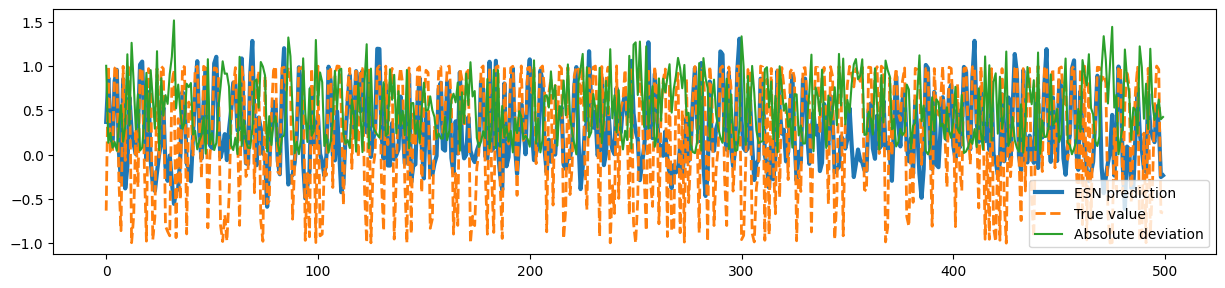

R2 = 0.31230006953399914, RMSE = 0.3125110182088758


In [138]:
units = 200
leak_rate = 0.3
spectral_radius = 1.25
input_scaling = 1.0
connectivity = 0.1
input_connectivity = 0.2
seed = 1234

from reservoirpy.nodes import FORCE

reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                      lr=leak_rate, rc_connectivity=connectivity,
                      input_connectivity=input_connectivity, seed=seed)

readout   = FORCE(1)


esn_online = reservoir >> readout

esn_online.train(X_train1, y_train1)

pred_online = esn_online.run(X_test1)  
plot_results(pred_online, y_test1, sample=500)

from reservoirpy.observables import nrmse, rsquare
print(f'R2 = {rsquare(y_test1, y_pred1)}, RMSE = {nrmse(y_test1, y_pred1)}')